# Regression Training — Spending Prediction

Trains a Random Forest regressor on raw numeric features to predict customer monetary spending.

Prerequisites: `preprocess_regression.ipynb`

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

In [2]:
DATA_DIR   = '../data/regression_specific'
MODELS_DIR = '../models'
REPORTS_DIR = '../output'
MODEL_PATH  = f'{MODELS_DIR}/regression_model.pkl'

RANDOM_STATE     = 42
N_ESTIMATORS     = 200
MAX_DEPTH        = 15
MIN_SAMPLES_SPLIT = 5
CV_FOLDS         = 5

## 1. Load Data

In [3]:
for fname in ['X_train_reg.csv', 'X_test_reg.csv', 'y_train_reg.csv', 'y_test_reg.csv']:
    assert os.path.exists(f'{DATA_DIR}/{fname}'), (
        f"{DATA_DIR}/{fname} not found — run preprocess_regression.ipynb first."
    )

X_train = pd.read_csv(f'{DATA_DIR}/X_train_reg.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test_reg.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train_reg.csv').values.ravel()
y_test  = pd.read_csv(f'{DATA_DIR}/y_test_reg.csv').values.ravel()

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")

✅ Train: (2405, 31) | Test: (602, 31)


## 2. Log Transformation

In [4]:
y_train_log = np.log1p(np.maximum(y_train, 0))
y_test_log  = np.log1p(np.maximum(y_test, 0))

print(f"✅ Log transform applied.")
print(f"   y_train — before: mean={y_train.mean():.2f}  after: mean={y_train_log.mean():.4f}")
print(f"   y_test  — before: mean={y_test.mean():.2f}  after: mean={y_test_log.mean():.4f}")

✅ Log transform applied.
   y_train — before: mean=1466.32  after: mean=6.5162
   y_test  — before: mean=1539.70  after: mean=6.5179


## 3. Cross-Validation

In [5]:
model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_scores = cross_val_score(model, X_train, y_train_log, cv=CV_FOLDS, scoring='r2')

print(f"✅ {CV_FOLDS}-fold CV complete.")
print(f"   R² per fold : {cv_scores.round(4)}")
print(f"   Mean R²     : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

✅ 5-fold CV complete.
   R² per fold : [0.9683 0.9653 0.9673 0.9637 0.961 ]
   Mean R²     : 0.9651 (+/- 0.0052)


## 4. Training

In [6]:
model.fit(X_train, y_train_log)
print(f"✅ Model trained on {X_train.shape[0]} samples, {X_train.shape[1]} features.")

✅ Model trained on 2405 samples, 31 features.


## 5. Evaluation

In [7]:
y_pred_log  = model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)

r2_log  = r2_score(y_test_log, y_pred_log)
r2_real = r2_score(y_test, y_pred_real)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred_real))
mae     = mean_absolute_error(y_test, y_pred_real)

metrics_df = pd.DataFrame({
    'Metric': ['R² (log scale)', 'R² (real scale)', f'CV R² mean ({CV_FOLDS}-fold)', 'RMSE (DT)', 'MAE (DT)'],
    'Value':  [r2_log, r2_real, cv_scores.mean(), rmse, mae]
})
metrics_df['Value'] = metrics_df['Value'].round(4)
metrics_df

,Metric,Value
0,R² (log scale),0.9625
1,R² (real scale),0.9099
2,CV R² mean (5-fold),0.9651
3,RMSE (DT),799.6425
4,MAE (DT),265.0135


## 6. Inference Test — First 3 Customers

In [8]:
rows = []
for i in range(3):
    real_val  = y_test[i]
    pred_real = np.expm1(model.predict(X_test.iloc[[i]]))[0]
    rows.append({
        'Customer': f'Client {i+1}',
        'Real (DT)': round(real_val, 2),
        'Predicted (DT)': round(pred_real, 2),
        'Gap (DT)': round(abs(real_val - pred_real), 2)
    })

print("✅ Inference test complete.")
pd.DataFrame(rows)

✅ Inference test complete.


,Customer,Real (DT),Predicted (DT),Gap (DT)
0,Client 1,110.95,101.02,9.93
1,Client 2,1030.40,1901.95,871.55
2,Client 3,383.03,324.97,58.06


## 7. Save Model

In [9]:
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

✅ Model saved to: ../models/regression_model.pkl


## 8. Visualisations

✅ Report saved to: ../output/regression_raw_final_report.png


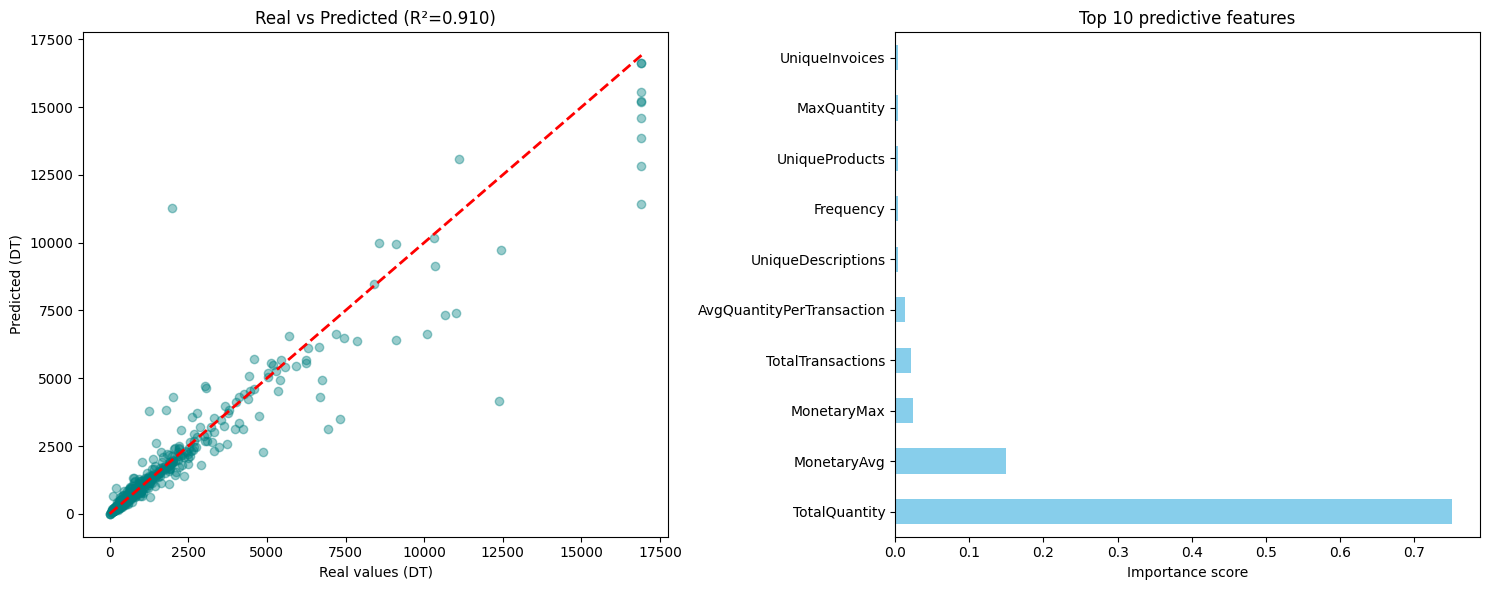

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred_real, alpha=0.4, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Real vs Predicted (R²={r2_real:.3f})')
axes[0].set_xlabel('Real values (DT)')
axes[0].set_ylabel('Predicted (DT)')

feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue', ax=axes[1])
axes[1].set_title('Top 10 predictive features')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
os.makedirs(REPORTS_DIR, exist_ok=True)
plt.savefig(f'{REPORTS_DIR}/regression_raw_final_report.png', dpi=150)
print(f"✅ Report saved to: {REPORTS_DIR}/regression_raw_final_report.png")
plt.show()

## Summary

In [11]:
print("=" * 50)
print("    REGRESSION TRAINING — COMPLETE")
print("=" * 50)
print(f"  R² (log scale)  : {r2_log:.4f}")
print(f"  R² (real scale) : {r2_real:.4f}")
print(f"  CV R² mean      : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"  RMSE            : {rmse:.2f} DT")
print(f"  MAE             : {mae:.2f} DT")
print("")
print(f"  Saved: {MODEL_PATH}")
print(f"  Saved: {REPORTS_DIR}/regression_raw_final_report.png")
print("")
print("  Next step: predict.ipynb")
print("=" * 50)

    REGRESSION TRAINING — COMPLETE
  R² (log scale)  : 0.9625
  R² (real scale) : 0.9099
  CV R² mean      : 0.9651 (+/- 0.0052)
  RMSE            : 799.64 DT
  MAE             : 265.01 DT

  Saved: ../models/regression_model.pkl
  Saved: ../output/regression_raw_final_report.png

  Next step: predict.ipynb
